# Exercise 3: Run HBV model with ERA5 forcing and GRDC observation

In this notebook you will run your own HBV model using ERA5 forcing data (from the previous notebook) and GRDC observation data. You will have to change a few settings below. Read carefully and decide which inputs and lines you need to change.

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load all dependencies, including your own model through ewatercycle_wrapper_HBV
import ewatercycle.forcing
import ewatercycle.observation.grdc
import ewatercycle.analysis
from pathlib import Path
from cartopy.io import shapereader
import pandas as pd
import numpy as np
from rich import print
import matplotlib.pyplot as plt
import xarray as xr

from ewatercycle_wrapper_HBV import HBV
 


Add the name of your region in the cell below:

In [3]:
# Name of your shapefile/region without extension:
own_region = "Cagayan_de_Oro" #for example: "Rhine"

if own_region == None: # if nothing is provided, the Rhine shapefile will be used
    own_region = "Rhine"

In [4]:
# Shapefile that describes the basin we want to study.
path = Path.cwd()
forcing_path = path / "Forcing"
shapeFile = forcing_path / f"{own_region}.shp"

# Location to saved forcing results from previous notebook
forcingLocation = forcing_path / f"{own_region}_1991_2019_Forcing"

# GRDC station ID for the observation station
#grdc_station_id = "6335020"  # GRDC station ID
#basin_name = own_region

# Period of interest. Make sure that GRDC data is available for this period and that.
experiment_start_time = "1995-01-01T00:00:00Z"
experiment_end_time = "1999-12-31T00:00:00Z"

Forcing was created in the previous notebook and loaded here.

In [5]:
ERA5_forcing = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(forcingLocation)
print(ERA5_forcing)

LumpedMakkinkForcing(
    start_time='1991-01-01T00:00:00Z',
    end_time='2019-12-31T00:00:00Z',
    directory=PosixPath('/home/group6/teaching-materials/Course Exercises 
/Forcing/Cagayan_de_Oro_1991_2019_Forcing'),
    shape=PosixPath('/home/group6/teaching-materials/Course Exercises 
/Forcing/Cagayan_de_Oro_1991_2019_Forcing/Cagayan_de_Oro.shp'),
    filenames={
        'pr': 'OBS6_ERA5_reanaly_1_day_pr_1991-2019.nc',
        'tas': 'OBS6_ERA5_reanaly_1_day_tas_1991-2019.nc',
        'rsds': 'OBS6_ERA5_reanaly_1_day_rsds_1991-2019.nc',
        'evspsblpot': 'Derived_Makkink_evspsblpot.nc'
    }
)

Now we can prepare the configuration files just as in the first notebook. Note that we are using the same parameters as in the first notebook which will not be adequate for your new area (but might be pretty ok, let's see!):

In [6]:
s_0 = np.array([0,  100,  0,  5])

p_min_initial = np.array([0,   0.2,  40,    .5,   .001,   1,     .01,  .0001])
p_max_initial = np.array([8,    1,  800,   4,    .3,     10,    .1,   .01])

p_names = ["$I_{max}$",  "$C_e$",  "$Su_{max}$", "β",  "$P_{max}$",  "$T_{lag}$",   "$K_f$",   "$K_s$"]
S_names = ["Interception storage", "Unsaturated Rootzone Storage", "Fastflow storage", "Groundwater storage"]

param_names = ["Imax","Ce",  "Sumax", "beta",  "Pmax",  "Tlag",   "Kf",   "Ks"]

par_0 = (p_min_initial + p_max_initial)/2

In [7]:
model = HBV(forcing=ERA5_forcing)

In [8]:
config_file, _ = model.setup(
                            parameters=','.join([str(p) for p in par_0]),
                            initial_storage=','.join([str(s) for s in s_0]),
                               )

In [9]:
model.initialize(config_file)

Now it is time again to run the HBV model:

In [10]:
Q_m = []
time = []
while model.time < model.end_time:
    model.update()
    discharge_this_timestep = model.get_value("Q")
    Q_m.append(discharge_this_timestep[0])
    time.append(pd.Timestamp(model.time_as_datetime.date()))

In [11]:
df = pd.DataFrame(data=Q_m,columns=["Modeled discharge"], index=time)

We can plot the output discharge directly using the DataFrame.

Text(0.5, 0, 'Time')

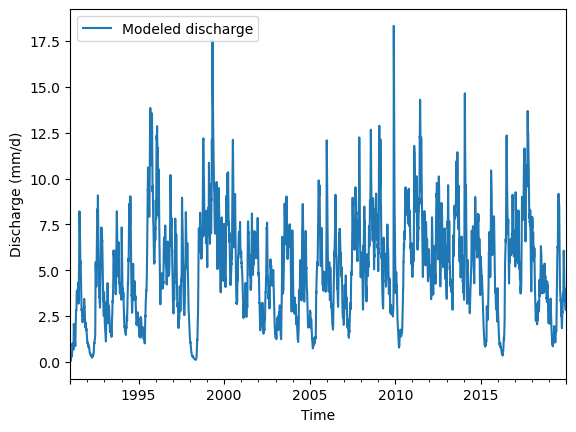

In [12]:
fig, ax = plt.subplots(1,1)

df.plot(ax=ax,label="Modeled discharge HBV-bmi")
plt.ylabel(f"Discharge ({model.bmi.get_var_units('Q')})")
plt.xlabel("Time")

## Analyse results
We can also use the ```hydrograph``` function from eWaterCycle. This will make a hydrograph that compares model output to observations. For this we need to load observations and make sure that the observations and model output are in the same units. Observations typically are in m$^3$/s. 

Note that the unit of discharge from this model is in mm/d. Conversion to m$^3$/s requires the area of the catchment.

In [13]:
shapeObject = shapereader.Reader(shapeFile.absolute())
record = next(shapeObject.records())
#shape_area = record.attributes["SUB_AREA"] * 1e6
shape_area = 1083.18 * 1000000 # m2
print("The catchment area is:", shape_area, 'm2')

The catchment area is: 1083180000.0 m2

The hydrograph function requires xarrays. We use the DataFrame ```df``` and convert the discharge to m$^3$ per second. Then we convert it to a ```xarray```

In [14]:
df['model output'] = df['Modeled discharge'] * shape_area / (1000 * 86400)
sim_data = df['model output'].to_xarray().rename({'index': 'date'}) 
sim_data.name = 'Simulated data'
sim_data

<xarray.DataArray 'Simulated data' (date: 10591)> Size: 85kB
array([1.77105746e-02, 7.08753726e-02, 1.59558350e-01, ...,
       4.11550765e+01, 4.05150031e+01, 3.93834946e+01])
Coordinates:
  * date     (date) datetime64[ns] 85kB 1991-01-02 1991-01-03 ... 2019-12-31

The observation data is loaded using ```the get_grdc_data()``` function build into eWaterCycle. The GRDC data is given as a xarray object. The observation data and discharge data are combined together into one xarray. Note that we re-index the discharge data to make sure they are at the same timestamp.

In [15]:
# observations = ewatercycle.observation.grdc.get_grdc_data(
#     station_id=grdc_station_id,
#     start_time=experiment_start_time,
#     end_time=experiment_end_time,
#     column='Observations from GRDC',
# )

In [16]:
obs = pd.read_excel('Discharge_19912019_Cagayan.xlsx', index_col=[0])

In [17]:
obs = obs / 1000
obs.loc[obs['Q'] > 4000, 'Q'] = np.nan
obs.head()

obs = obs.loc['1991-01-01':'1994-12-31']
obs_data = obs['Q'].to_xarray().rename({'Day': 'date'})
obs_data.name = 'Observed data'

Have a look at the DataFrame with the model output and the observations from GRDC:

In [18]:
# discharge = xr.merge([sim_data, observations["Observations from GRDC"]]).to_dataframe()
# hydro_data = discharge[["Observations from GRDC", "Simulated data"]].dropna()
# hydro_data
discharge = xr.merge([sim_data, obs_data]).to_dataframe()
hydro_data = discharge[["Simulated data", "Observed data"]].dropna()
hydro_data

,Simulated data,Observed data
date,,
1991-01-16,2.092785,44.3
1991-01-17,2.317244,40.0
1991-01-18,2.477274,40.0
1991-01-19,2.558185,40.0
1991-01-20,2.628125,40.0
...,...,...
1994-12-27,29.573525,59.2
1994-12-28,29.028603,57.6
1994-12-29,28.057666,57.6


Finally plot the hydrograph. It is remarkabe to see how well a simple model like HBV, without calibration, is already able to predict discharge in the Rhine. Is it also good for your own area? 

(<Figure size 1000x1000 with 2 Axes>,
 (<Axes: title={'center': 'Hydrograph'}, xlabel='date', ylabel='Discharge (m$^3$ s$^{-1}$)'>,
  <Axes: >))

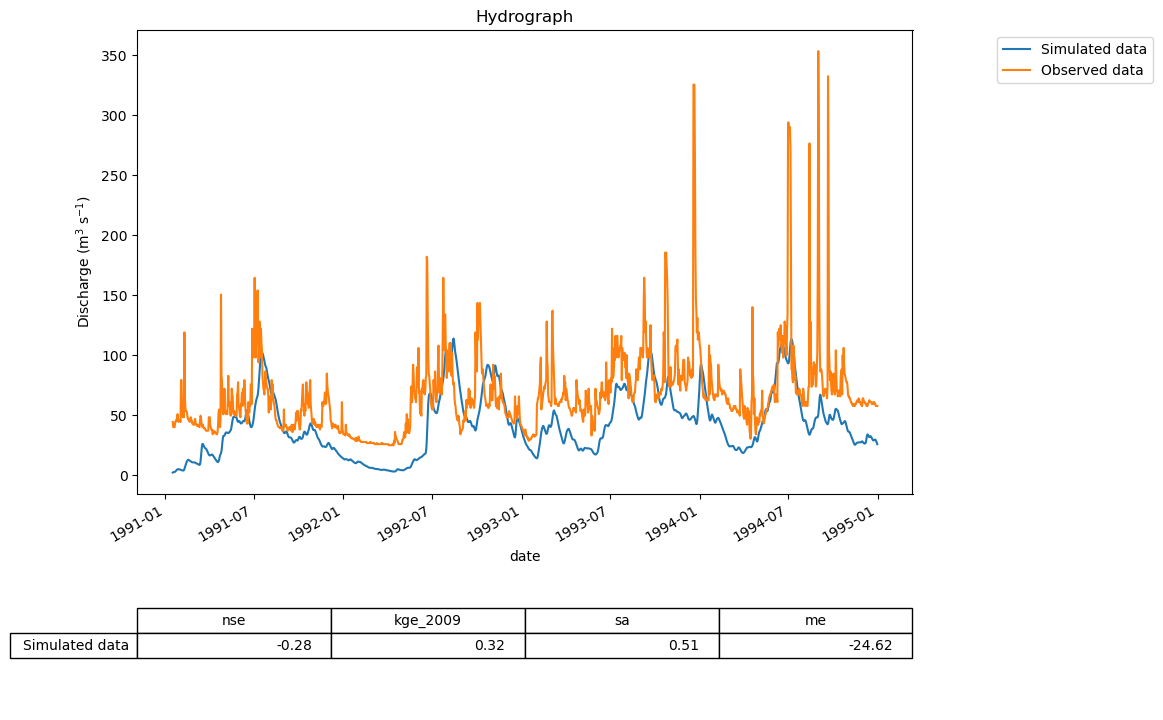

In [19]:
# Plot hydrograph and show metrics
ewatercycle.analysis.hydrograph(hydro_data, reference='Observed data', filename = 'experiment_hydrograph.png')

It is good practice to remove a model object when done using ```.finalize()```. For small models like this, it doesn't matter too much, but larger models that run in containers keep using resources when not ```finalized```.

In [20]:
model.finalize()

## Test with calibrated parameters

In [21]:
# Test Calibrated Parameters

p1 = np.array([2.30217914e+00, 5.82136251e-01, 7.80053510e+02, 1.01243743e+00, 2.89364414e-01, 1.06375915e+00, 3.25619436e-02, 4.08444666e-03])

In [22]:
model1 = HBV(forcing=ERA5_forcing)

In [23]:
config_file1, _ = model1.setup(
                            parameters=','.join([str(p) for p in p1]),
                            initial_storage=','.join([str(s) for s in s_0]),
                               )

In [24]:
model1.initialize(config_file1)

In [25]:
Q_m1 = []
time1 = []
while model1.time < model1.end_time:
    model1.update()
    discharge_this_timestep1 = model1.get_value("Q")
    Q_m1.append(discharge_this_timestep1[0])
    time1.append(pd.Timestamp(model1.time_as_datetime.date()))

In [26]:
df1 = pd.DataFrame(data=Q_m1,columns=["Modeled discharge (NSE)"], index=time1)

In [27]:
p2 = np.array([2.30217914e+00, 5.82136251e-01, 7.80053510e+02, 1.01243743e+00, 2.89364414e-01, 1.06375915e+00, 3.25619436e-02, 4.08444666e-03])

model2 = HBV(forcing=ERA5_forcing)

config_file2, _ = model2.setup(
                            parameters=','.join([str(p) for p in p2]),
                            initial_storage=','.join([str(s) for s in s_0]),
                               )

model2.initialize(config_file2)

Q_m2 = []
time2 = []
while model2.time < model2.end_time:
    model2.update()
    discharge_this_timestep2 = model2.get_value("Q")
    Q_m2.append(discharge_this_timestep2[0])
    time2.append(pd.Timestamp(model2.time_as_datetime.date())) 
    
df2 = pd.DataFrame(data=Q_m2,columns=["Modeled discharge (logNSE)"], index=time2)

Text(0.5, 0, 'Time')

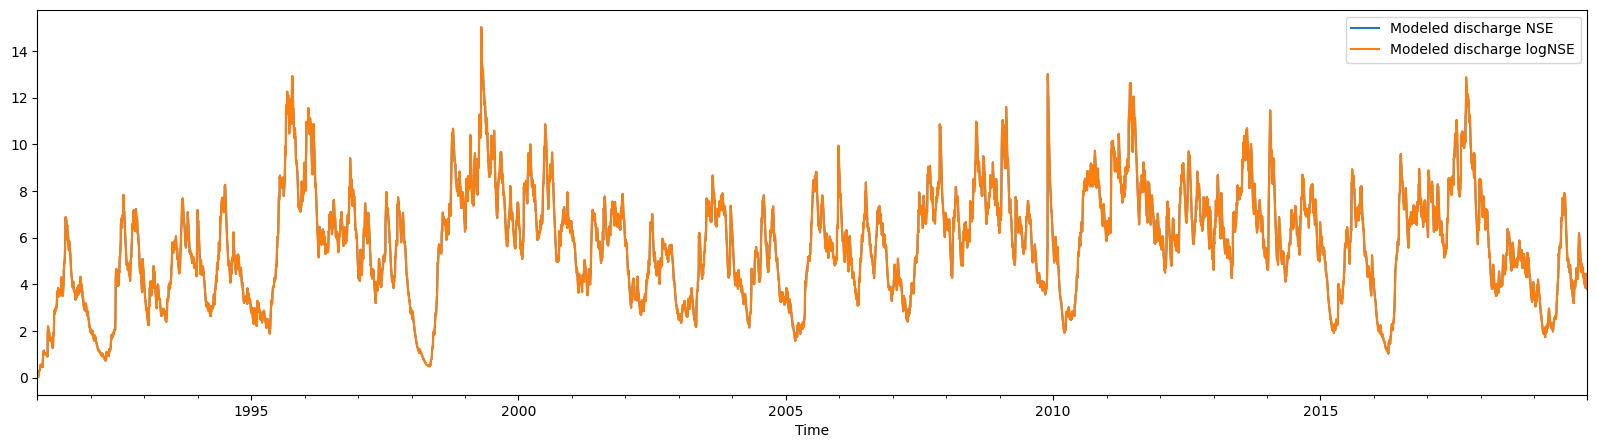

In [28]:
plt.figure(figsize=(20, 5))
# fig, ax = plt.subplots(1,1)

df1["Modeled discharge (NSE)"].plot(label="Modeled discharge NSE")
df2["Modeled discharge (logNSE)"].plot(label="Modeled discharge logNSE")
plt.legend()
# plt.ylabel(f"Discharge ({model.bmi.get_var_units('Q')})")
plt.xlabel("Time")

In [29]:
df1["Modeled discharge (NSE)"] = df1["Modeled discharge (NSE)"] * shape_area / (1000 * 86400)
sim_data1 = df1["Modeled discharge (NSE)"].to_xarray().rename({'index': 'date'}) 
sim_data1.name = 'Simulated data NSE'
sim_data1

<xarray.DataArray 'Simulated data NSE' (date: 10591)> Size: 85kB
array([ 0.25791391,  0.2587301 ,  0.25952548, ..., 50.51367731,
       49.05642489, 47.55994704])
Coordinates:
  * date     (date) datetime64[ns] 85kB 1991-01-02 1991-01-03 ... 2019-12-31

In [30]:
df2["Modeled discharge (logNSE)"] = df2["Modeled discharge (logNSE)"] * shape_area / (1000 * 86400)
sim_data2 = df2["Modeled discharge (logNSE)"].to_xarray().rename({'index': 'date'}) 
sim_data2.name = 'Simulated data logNSE'
sim_data2

<xarray.DataArray 'Simulated data logNSE' (date: 10591)> Size: 85kB
array([ 0.25791391,  0.2587301 ,  0.25952548, ..., 50.51367731,
       49.05642489, 47.55994704])
Coordinates:
  * date     (date) datetime64[ns] 85kB 1991-01-02 1991-01-03 ... 2019-12-31

In [31]:
discharge = xr.merge([sim_data1, sim_data2, obs_data]).to_dataframe()
hydro_data = discharge[["Simulated data NSE", "Simulated data logNSE", "Observed data"]].dropna()
hydro_data = hydro_data.loc['1991-01-01':'1994-12-31']
hydro_data

,Simulated data NSE,Simulated data logNSE,Observed data
date,,,
1991-01-16,4.085513,4.085513,44.3
1991-01-17,4.187417,4.187417,40.0
1991-01-18,4.144271,4.144271,40.0
1991-01-19,4.216833,4.216833,40.0
1991-01-20,5.173243,5.173243,40.0
...,...,...,...
1994-12-27,39.451332,39.451332,59.2
1994-12-28,38.448718,38.448718,57.6
1994-12-29,37.704687,37.704687,57.6


(<Figure size 1000x1000 with 2 Axes>,
 (<Axes: title={'center': 'Hydrograph Cagayan on Calibration Time'}, xlabel='date', ylabel='Discharge (m$^3$ s$^{-1}$)'>,
  <Axes: >))

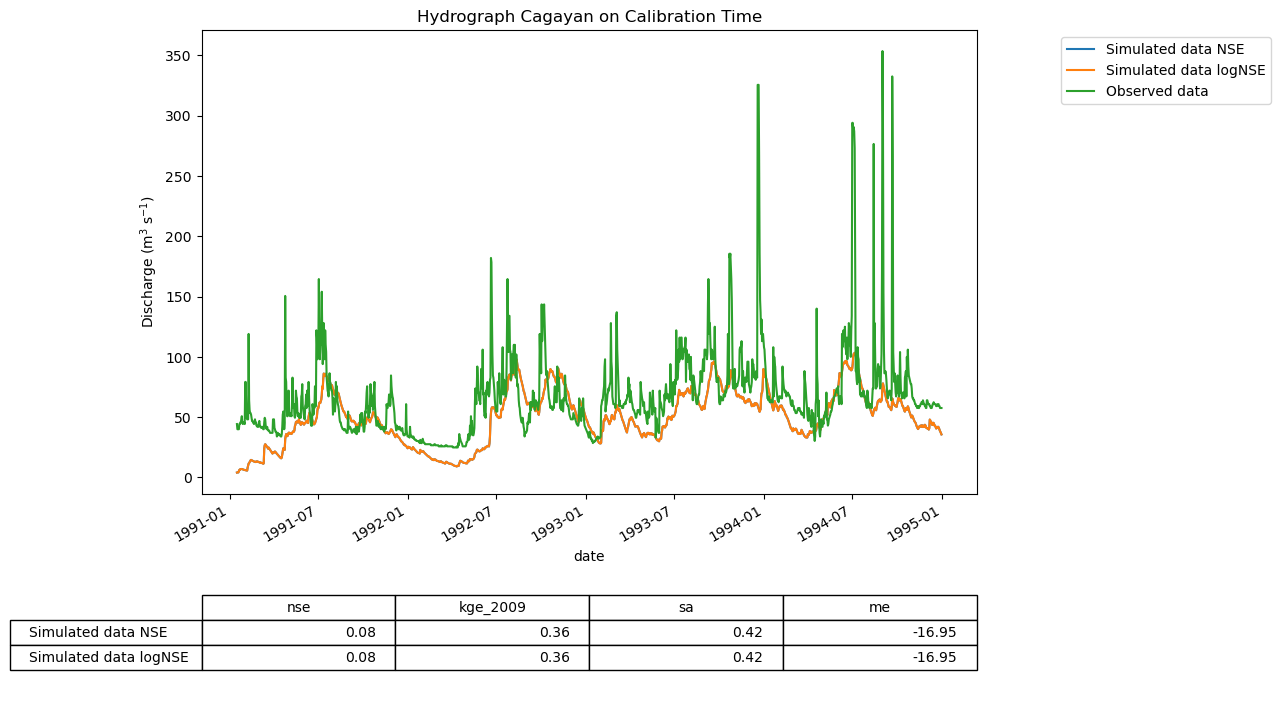

In [32]:
# Plot hydrograph and show metrics
ewatercycle.analysis.hydrograph(hydro_data, reference='Observed data', filename = 'experiment_hydrograph.png', title='Hydrograph Cagayan on Calibration Time')

In [33]:
print(model1.get_value("Si"))
print(model1.get_value("Su"))
print(model1.get_value("Sf"))
print(model1.get_value("Ss"))

[2.30217914]

[425.21232611]

[107.95669302]

[39.020045]